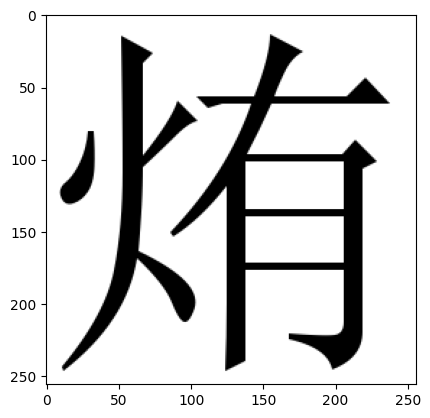

In [13]:
from fontTools.ttLib import TTFont
from fontTools.pens.freetypePen import FreeTypePen
from fontTools.misc.transform import Offset

pen = FreeTypePen(None) # 实例化Pen子类
font = TTFont("simsun.ttf") # 实例化TTFont
glyph = font.getGlyphSet()["uni70E0"] # 通过字形名称选择某一字形对象
glyph.draw(pen) # “画”出字形轮廓
width, ascender, descender = glyph.width, font['OS/2'].usWinAscent, -font['OS/2'].usWinDescent # 获取字形的宽度和上沿以及下沿
height = ascender - descender # 利用上沿和下沿计算字形高度
pen.show(width=width, height=height, transform=Offset(0, -descender)) # 显示以及矫正


In [32]:
from fontTools.ttLib import TTFont
from fontTools.pens.ttGlyphPen import TTGlyphPointPen

font = TTFont("simsun.ttf")
glyph = font['glyf']["uni70E0"]

coordinates = list(glyph.coordinates)
endPts = glyph.endPtsOfContours
flags = list(glyph.flags)

contours = []
contour = []
for i, (x,y) in enumerate(coordinates):
    contour.append((x,y,flags[i]))
    if i in endPts:
        contours.append(contour)
        contour = []

#print(contours)

pen = TTGlyphPointPen(None)
beginflag = 0
for i, pt in enumerate(coordinates):
    if pen._isClosed():
        pen.beginPath()
    if flags[i] == 1:
        pen.addPoint(pt,segmentType="line")
    else:
        pen.addPoint(pt)
    if i in endPts:
        pen.endPath()